In [2]:
# ============================================
# Import Required Libraries
# ============================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

# Save and Load Models
import joblib

# Create directories
import os

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

Matplotlib is building the font cache; this may take a moment.


In [3]:
# ============================================
# Load Dataset
# ============================================

# Load the dataset
df = pd.read_csv("../bank.csv")  # If notebook is inside notebooks/

# Display the first five rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [11]:
print("Dataset Shape:", df.shape)

print(f"\nNumber of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

print("\nDataset Details:")
df.info()

Dataset Shape: (11162, 17)

Number of Rows    : 11162
Number of Columns : 17

Dataset Details:
<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 2.0 MB


Statistical Summary

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,11162.0,41.231948,11.913369,18.0,32.0,39.0,49.00,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.00,81204.0
day,11162.0,15.658036,8.420740,1.0,8.0,15.0,22.00,31.0
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.00,3881.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,2.0,3.00,63.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,20.75,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,1.00,58.0


Check Missing Values

In [13]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing_summary

,Missing Values,Percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


Check Duplicate Records

In [14]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


Split Features and Target

In [16]:
# Separate input features and target variable
X = df.drop("deposit", axis=1)
y = df["deposit"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

Feature Matrix Shape : (11162, 16)
Target Vector Shape  : (11162,)
Training Samples : 8929
Testing Samples  : 2233


Create Training Dataset for EDA

In [17]:
train_df = X_train.copy()
train_df["deposit"] = y_train

train_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
8644,46,admin.,married,secondary,no,526,no,yes,cellular,31,jul,251,3,-1,0,unknown,no
2632,46,admin.,married,tertiary,no,2552,no,no,cellular,3,sep,260,1,94,8,success,yes
3056,25,technician,single,secondary,no,139,no,yes,cellular,11,jan,202,1,91,1,success,yes
1080,43,technician,married,secondary,no,3288,yes,no,cellular,21,nov,775,3,-1,0,unknown,yes
4006,37,blue-collar,single,unknown,no,217,no,no,cellular,23,sep,272,2,-1,0,unknown,yes


EDA On Training Data

In [18]:
print("="*60)
print("Training Dataset Shape")
print("="*60)

print(f"Rows    : {train_df.shape[0]}")
print(f"Columns : {train_df.shape[1]}")

Training Dataset Shape
Rows    : 8929
Columns : 17


In [19]:
target_distribution = pd.DataFrame({
    "Count": train_df["deposit"].value_counts(),
    "Percentage (%)": (
        train_df["deposit"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

target_distribution

,Count,Percentage (%)
deposit,,
no,4698,52.62
yes,4231,47.38


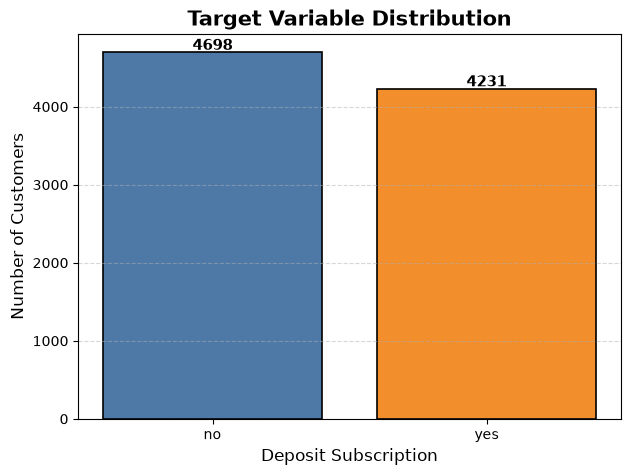

In [21]:
# Class distribution
deposit_counts = train_df["deposit"].value_counts()

plt.figure(figsize=(7,5))

colors = ["#4E79A7", "#F28E2B"]

bars = plt.bar(
    deposit_counts.index,
    deposit_counts.values,
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

plt.title("Target Variable Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Deposit Subscription", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 30,
        f"{int(bar.get_height())}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.show()

Numerical Feature Distribution

Numerical Features
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical Features
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


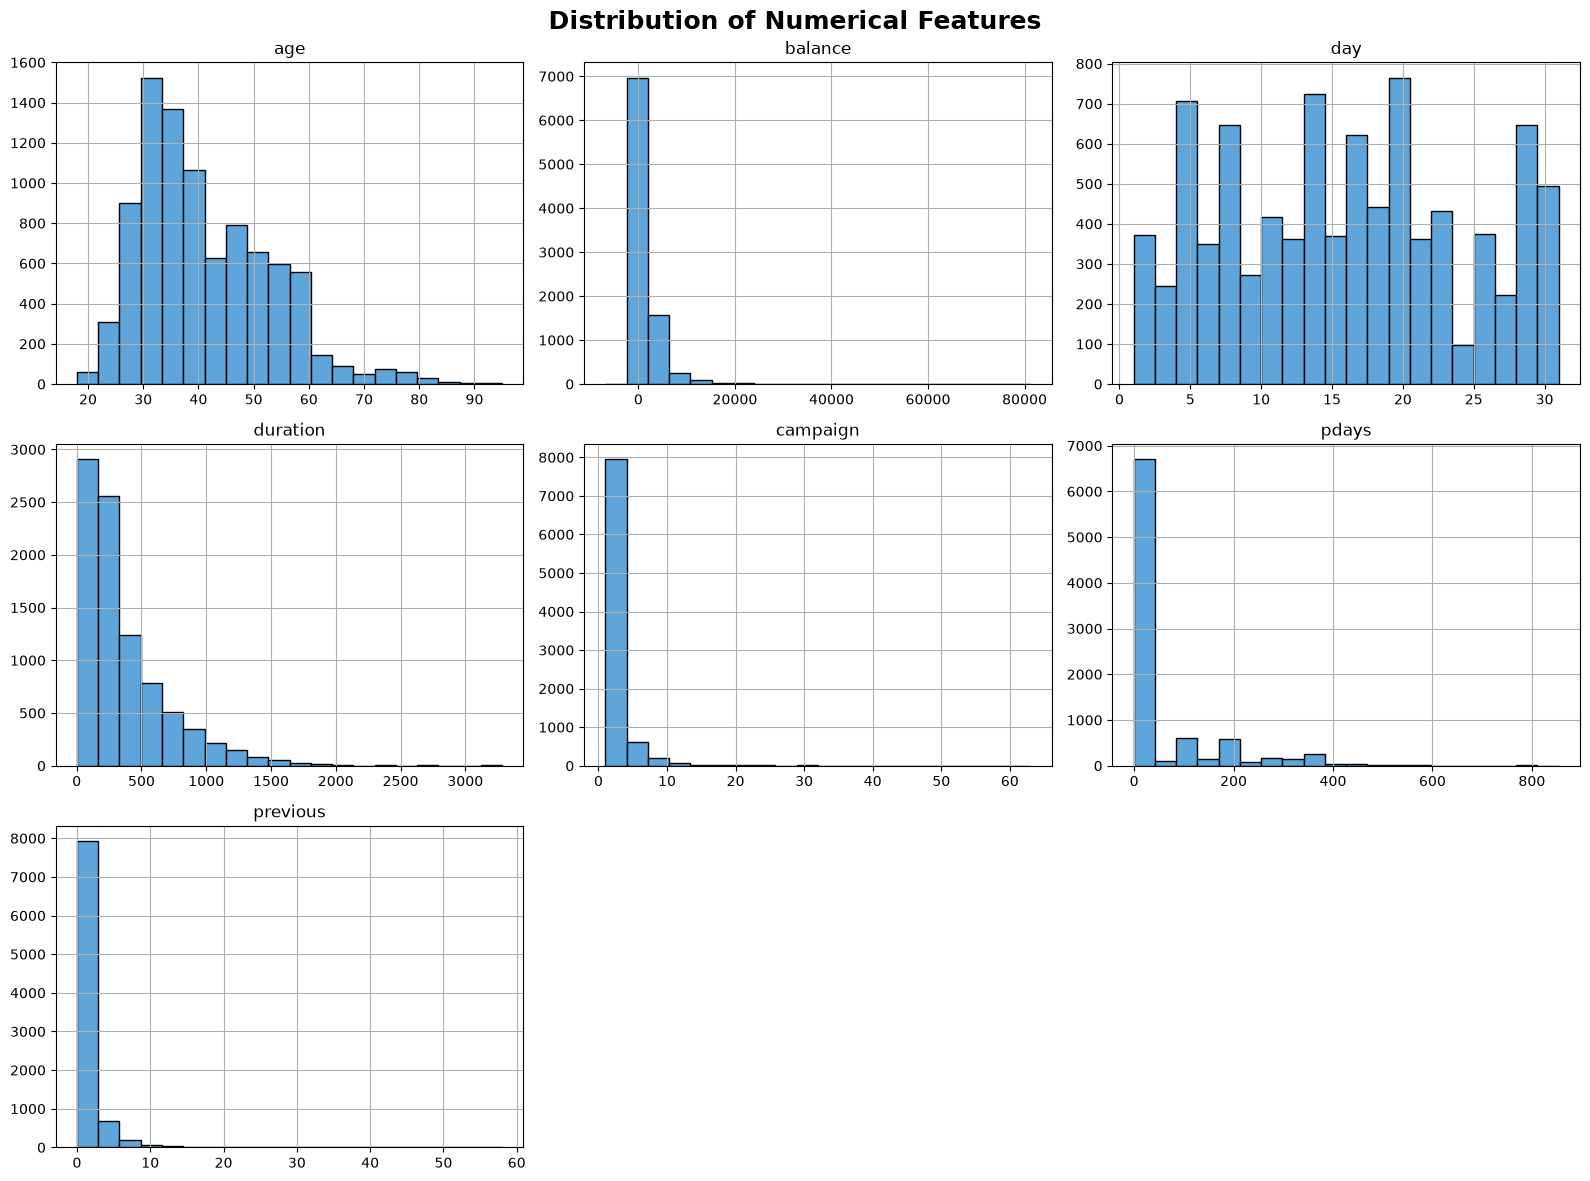

In [23]:
# ==========================================
# Identify Numerical and Categorical Features
# ==========================================

# Numerical features
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical features
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features")
print(numerical_features)

print("\nCategorical Features")
print(categorical_features)

train_df[numerical_features].hist(
    figsize=(16,12),
    bins=20,
    color="#5DA5DA",
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

Categorical Feature Distribution

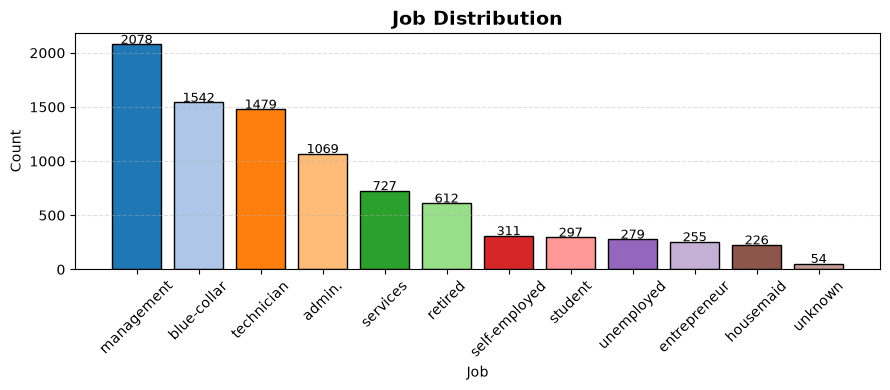

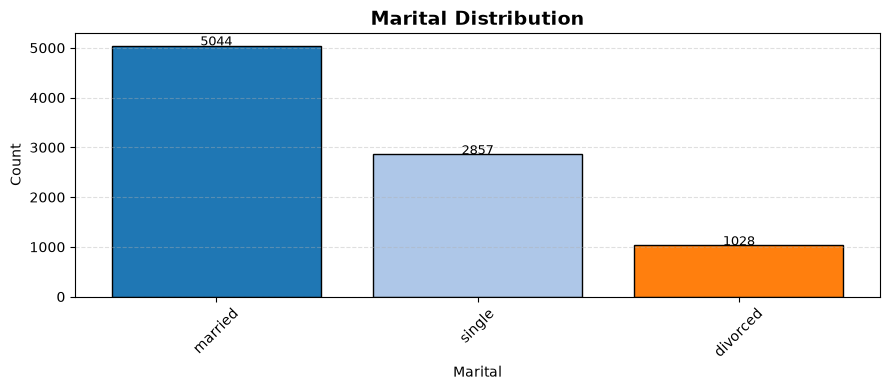

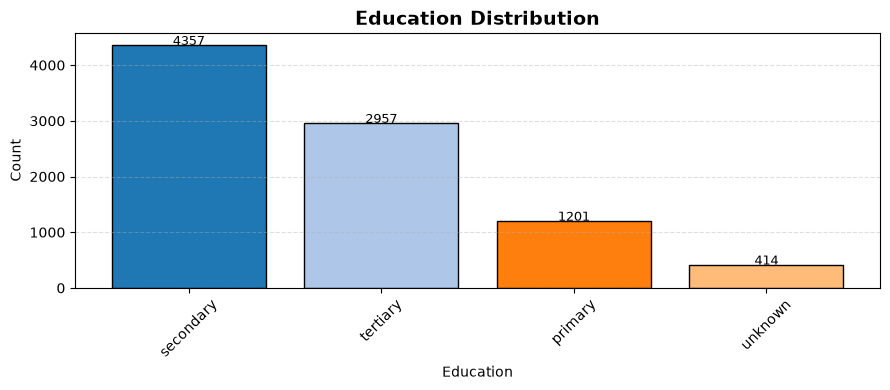

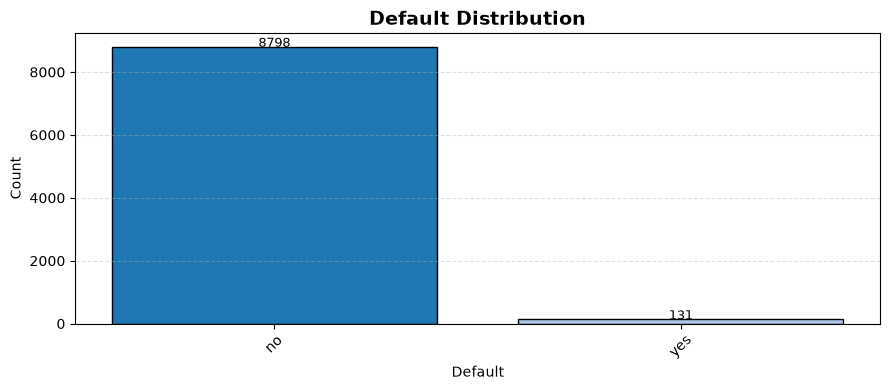

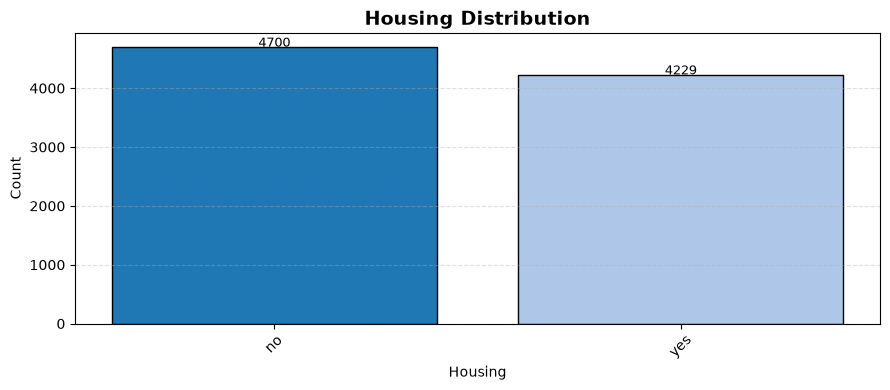

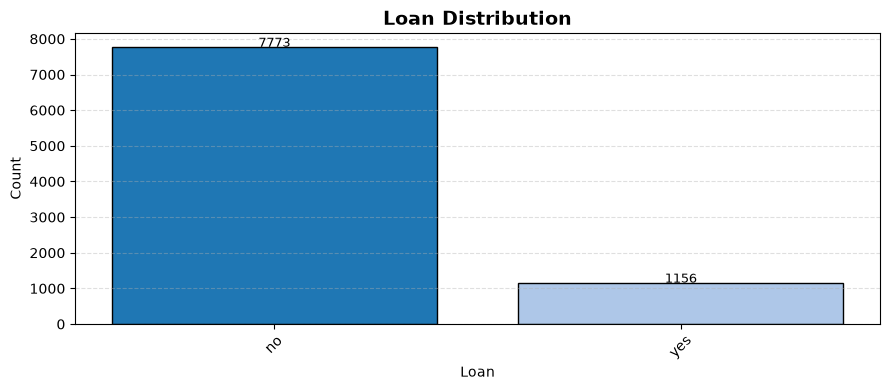

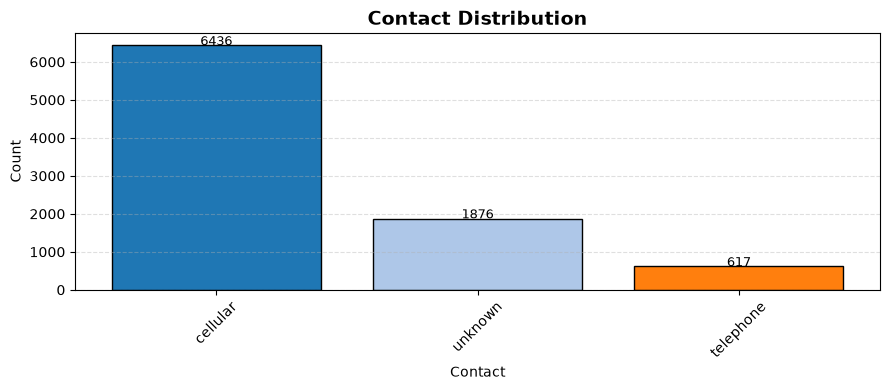

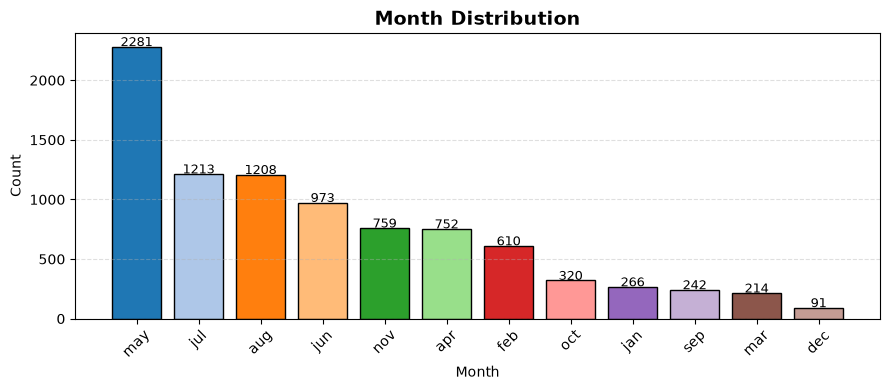

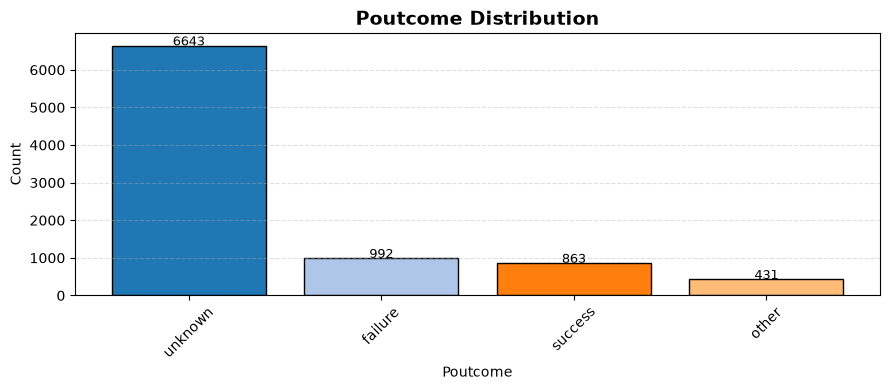

In [24]:
for feature in categorical_features:

    counts = train_df[feature].value_counts()

    plt.figure(figsize=(9,4))

    bars = plt.bar(
        counts.index,
        counts.values,
        color=plt.cm.tab20.colors[:len(counts)],
        edgecolor="black"
    )

    plt.title(
        f"{feature.title()} Distribution",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(feature.title())
    plt.ylabel("Count")

    plt.xticks(rotation=45)

    plt.grid(axis="y", linestyle="--", alpha=0.4)

    # Value labels
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            int(bar.get_height()),
            ha="center",
            fontsize=9
        )

    plt.tight_layout()

    plt.show()

Correlation Heatmap

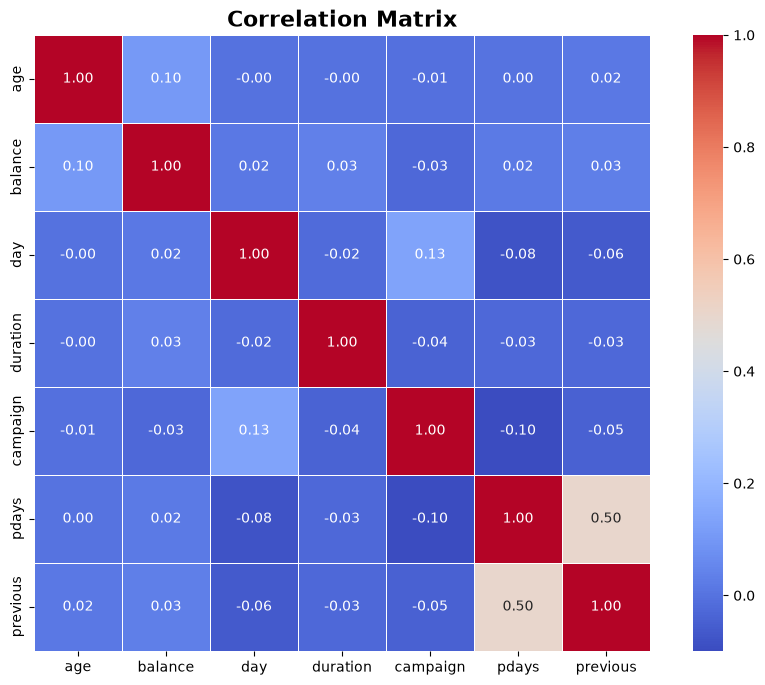

In [25]:
import seaborn as sns

plt.figure(figsize=(11,8))

sns.heatmap(
    train_df[numerical_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.show()

Data Preprocessing

One-Hot Encoding for categorical features

In [26]:
# Separate numerical and categorical features
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X_train.select_dtypes(include=["object"]).columns

print("Numerical Features")
print(numerical_features)

print("\nCategorical Features")
print(categorical_features)

# Apply One-Hot Encoding
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True
)

# Ensure both datasets have identical columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print(X_train_encoded.shape)
print(X_test_encoded.shape)

Numerical Features
Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='str')

Categorical Features
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='str')
(8929, 42)
(2233, 42)


## 5.3 Align Feature Columns

After One-Hot Encoding, the training and testing datasets are aligned to ensure they contain identical feature columns.

In [27]:
# ==========================================
# Align Train and Test Data
# ==========================================

X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

Encode the Target Variable

In [28]:
# ==========================================
# Encode Target Variable
# ==========================================

y_train_encoded = y_train.map({
    "no": 0,
    "yes": 1
})

y_test_encoded = y_test.map({
    "no": 0,
    "yes": 1
})

In [30]:
print("=" * 50)
print("Training Dataset Shape :", X_train_encoded.shape)
print("Testing Dataset Shape  :", X_test_encoded.shape)

print("\nEncoded Target Classes:")
print(y_train_encoded.value_counts())

X_train_encoded.head()

Training Dataset Shape : (8929, 42)
Testing Dataset Shape  : (2233, 42)

Encoded Target Classes:
deposit
0    4698
1    4231
Name: count, dtype: int64


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
8644,46,526,31,251,3,-1,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2632,46,2552,3,260,1,94,8,False,False,False,...,False,False,False,False,False,False,True,False,True,False
3056,25,139,11,202,1,91,1,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1080,43,3288,21,775,3,-1,0,False,False,False,...,False,False,False,False,True,False,False,False,False,True
4006,37,217,23,272,2,-1,0,True,False,False,...,False,False,False,False,False,False,True,False,False,True


## Feature Scaling

Feature scaling standardizes the numerical features to have a mean of 0 and a standard deviation of 1. This is required for distance-based and gradient-based algorithms such as Logistic Regression and K-Nearest Neighbors (KNN).

The scaled datasets are stored separately so that:

- Logistic Regression and KNN use the scaled datasets.
- Decision Tree, Gaussian Naive Bayes, and Random Forest use the original encoded datasets.

In [32]:
# ==========================================
# Feature Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Create copies of the encoded datasets
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

# Scale ONLY the original numerical features
X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train_encoded[numerical_features]
)

X_test_scaled[numerical_features] = scaler.transform(
    X_test_encoded[numerical_features]
)

print("Feature scaling completed successfully.")

print("\nScaled Training Dataset Shape :", X_train_scaled.shape)
print("Scaled Testing Dataset Shape  :", X_test_scaled.shape)

Feature scaling completed successfully.

Scaled Training Dataset Shape : (8929, 42)
Scaled Testing Dataset Shape  : (2233, 42)


# 💾 Save Processed Datasets

The processed datasets are saved to the **data** directory for use in the model training notebook.

The following files are generated:

- X_train_encoded.csv
- X_test_encoded.csv
- X_train_scaled.csv
- X_test_scaled.csv
- y_train_encoded.csv
- y_test_encoded.csv
- scaler.pkl

This modular approach improves readability, reproducibility, and avoids repeating preprocessing steps during model training.

In [34]:
# ==========================================
# Save Processed Datasets
# ==========================================

import os
import joblib

# Create the data directory if it doesn't exist
os.makedirs("../data", exist_ok=True)

# ------------------------------------------
# Save Encoded Feature Datasets
# ------------------------------------------

X_train_encoded.to_csv(
    "../data/X_train_encoded.csv",
    index=False
)

X_test_encoded.to_csv(
    "../data/X_test_encoded.csv",
    index=False
)

# ------------------------------------------
# Save Scaled Feature Datasets
# ------------------------------------------

X_train_scaled.to_csv(
    "../data/X_train_scaled.csv",
    index=False
)

X_test_scaled.to_csv(
    "../data/X_test_scaled.csv",
    index=False
)

# ------------------------------------------
# Save Encoded Target Variables
# ------------------------------------------

y_train_encoded.to_frame(name="deposit").to_csv(
    "../data/y_train_encoded.csv",
    index=False
)

y_test_encoded.to_frame(name="deposit").to_csv(
    "../data/y_test_encoded.csv",
    index=False
)

# ------------------------------------------
# Save Standard Scaler
# ------------------------------------------

joblib.dump(
    scaler,
    "../data/scaler.pkl"
)

# ------------------------------------------
# Display Success Message
# ------------------------------------------

print("=" * 60)
print("      DATA PREPARATION COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nFiles Saved Successfully:\n")

print("📁 data/")
print("   ├── X_train_encoded.csv")
print("   ├── X_test_encoded.csv")
print("   ├── X_train_scaled.csv")
print("   ├── X_test_scaled.csv")
print("   ├── y_train_encoded.csv")
print("   ├── y_test_encoded.csv")
print("   └── scaler.pkl")

      DATA PREPARATION COMPLETED SUCCESSFULLY

Files Saved Successfully:

📁 data/
   ├── X_train_encoded.csv
   ├── X_test_encoded.csv
   ├── X_train_scaled.csv
   ├── X_test_scaled.csv
   ├── y_train_encoded.csv
   ├── y_test_encoded.csv
   └── scaler.pkl
